# 06 — Mask 3D Effects: RCWA, Topography & Phase

This notebook explores **Mask-3D effects** in EUV lithography using Rigorous Coupled-Wave Analysis (RCWA):

1. **Thin-mask approximation** vs. **full RCWA**
2. **Absorber topography** — rigorous diffraction orders of a 60 nm Ta absorber on the Mo/Si mirror
3. **Phase effects & Best Focus Shift** from mask topography
4. **Polarisation** — TE vs TM
5. **Status of the Mask-3D integration** in the pipeline (`use_rcwa=True`)

**Why Mask-3D matters:** At EUV the absorber (~60 nm Ta) is *thick* compared to the wavelength (13.5 nm) and the feature size. Thin-mask approximations break down: diffraction orders become asymmetric, phase shifts appear, and best focus moves.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from euvsimulator.pipeline import SimulationConfig, run_simulation
from euvsimulator.mask3d.rcwa_torch import RCWAConfig, RCWA1D, binary_grating_profile
from euvsimulator.mask3d.geometry import standard_euv_mask, build_permittivity_profile
from euvsimulator.materials import CXROTable
from euvsimulator.optics.multilayer import mo_si_stack
from euvsimulator.optics.tmm import reflectivity


## 1. Reference: TMM Reflectivities (as used by the pipeline)

The current pipeline computes complex reflectivities of the absorber and space regions via TMM, then builds analytic Fourier coefficients.


In [2]:
period_nm = 64.0
line_width_nm = 32.0
wavelength_nm = 13.5
absorber_height_nm = 60.0
theta_deg = 6.0  # chief-ray angle at mask

table = CXROTable()
n_si, k_si = table.refractive_index("Si", 91.84)
n_sub = torch.tensor(complex(n_si, k_si), dtype=torch.complex128)

ml_stack = mo_si_stack(n_bilayers=50, d_mo_nm=2.8, d_si_nm=4.1,
                       capping_layer="Ru", d_cap_nm=2.5)

wl = torch.tensor([wavelength_nm * 1e-9], dtype=torch.float64)
theta_t = torch.tensor(np.radians(theta_deg), dtype=torch.float64)

# Space (ML only)
_, r_space = reflectivity(ml_stack.n_layers, ml_stack.thicknesses, wl, theta_t,
                          n_substrate=n_sub, roughness_nm=0.0)
r0_space = r_space[0]

# Absorber on ML
n_ta, k_ta = table.refractive_index("Ta", 91.84)
n_abs = torch.tensor(complex(n_ta, k_ta), dtype=torch.complex128)
d_abs = torch.tensor([absorber_height_nm * 1e-9], dtype=torch.float64)
full_n = torch.cat([n_abs.unsqueeze(0), ml_stack.n_layers])
full_d = torch.cat([d_abs, ml_stack.thicknesses])

_, r_ab = reflectivity(full_n, full_d, wl, theta_t,
                       n_substrate=n_sub, roughness_nm=0.0)
r0_abs = r_ab[0]

print(f"Space:    |r|² = {abs(r0_space)**2:.4f}, phase = {np.angle(r0_space):+.3f} rad")
print(f"Absorber: |r|² = {abs(r0_abs)**2:.4f}, phase = {np.angle(r0_abs):+.3f} rad")
print(f"Phase difference: {np.angle(r0_abs) - np.angle(r0_space):+.3f} rad")


Space:    |r|² = 0.6470, phase = +0.800 rad
Absorber: |r|² = 0.0129, phase = -2.359 rad
Phase difference: -3.159 rad


## 2. Thin-Mask Analytic Diffraction Orders

Binary complex mask: Fourier series of a rectangular reflectivity profile.


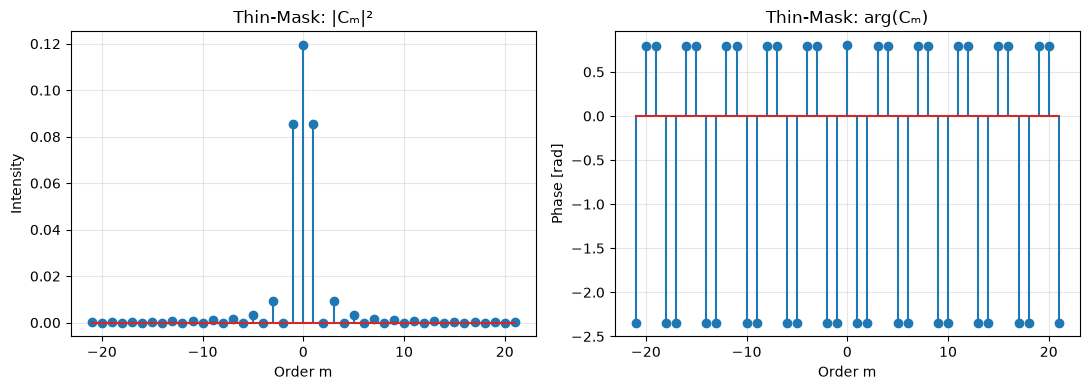

In [3]:
duty = line_width_nm / period_nm
n_orders = 21
order_indices = list(range(-n_orders, n_orders + 1))

a, b = r0_abs, r0_space
c0 = a * duty + b * (1.0 - duty)

amps_thin = torch.zeros(len(order_indices), dtype=torch.complex128)
for idx, m in enumerate(order_indices):
    if m == 0:
        amps_thin[idx] = c0
    else:
        amps_thin[idx] = (a - b) * np.sin(np.pi * m * duty) / (np.pi * m)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.stem(order_indices, np.abs(amps_thin.numpy())**2)
ax1.set_title("Thin-Mask: |Cₘ|²")
ax1.set_xlabel("Order m"); ax1.set_ylabel("Intensity")
ax1.grid(True, alpha=0.3)

ax2.stem(order_indices, np.angle(amps_thin.numpy()))
ax2.set_title("Thin-Mask: arg(Cₘ)")
ax2.set_xlabel("Order m"); ax2.set_ylabel("Phase [rad]")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Full RCWA — Rigorous Solution

The mask is solved at its physical size (4 × the wafer pitch, 6° chief-ray angle), exactly as the
pipeline does with `use_rcwa=True`: a 60 nm Ta grating above the Mo/Si mirror, which enters as an
order-diagonal reflection operator (`ml_stack`); the Ru capping layer belongs to the mirror.

In [4]:
from euvsimulator.mask3d.geometry import MaskLayer, MaskStack

M_demag = 4.0  # the RCWA sees the physical mask
mask = MaskStack(
    absorber_layers=[MaskLayer(material="Ta", thickness_nm=absorber_height_nm,
                               nk=complex(n_ta, k_ta), etched=True)],
    multilayer_bilayers=50, d_mo_nm=2.8, d_si_nm=4.1,
    substrate_nk=complex(n_si, k_si),
    period_nm=period_nm * M_demag, line_width_nm=line_width_nm * M_demag,
)
eps_profile, thicknesses, eps_sub = build_permittivity_profile(mask, n_samples=1024)
period_mask_m = period_nm * M_demag * 1e-9

print(f"ε profile samples: {eps_profile.shape[0]}")
print(f"Absorber thickness: {thicknesses[0].item() * 1e9:.1f} nm")
print(f"Mask period: {period_nm * M_demag:.0f} nm (wafer {period_nm:.0f} nm × {M_demag:.0f})")

ε profile samples: 1024
Absorber thickness: 60.0 nm
Mask period: 256 nm (wafer 64 nm × 4)


In [5]:
# RCWA for TE and TM polarisation, mirror as order-diagonal operator (as in the pipeline)
results = {}
for pol in ("TE", "TM"):
    cfg = RCWAConfig(
        wavelength=wavelength_nm * 1e-9,
        n_orders=21,
        theta=theta_deg,
        polarization=pol,
        device="cpu",
    )
    solver = RCWA1D(cfg)
    orders = solver.solve(
        eps_profile, thicknesses, period_mask_m,
        n_incident=torch.tensor([1.0 + 0.0j, 1.0 + 0.0j], dtype=torch.complex128),
        ml_stack=ml_stack,
    )
    results[pol] = (orders, solver.diffraction_efficiency(orders))

eff_te = results["TE"][1]
eff_tm = results["TM"][1]

print("Order |  Thin-mask  |  RCWA TE  |  RCWA TM")
print("------+-------------+-----------+---------")
for m in [-2, -1, 0, 1, 2]:
    thin = abs(amps_thin[n_orders + m].item())**2
    print(f"{m:+5d} | {thin:11.4f} | {eff_te.get(m, 0):9.4f} | {eff_tm.get(m, 0):9.4f}")

Order |  Thin-mask  |  RCWA TE  |  RCWA TM
------+-------------+-----------+---------
   -2 |      0.0000 |    0.0028 |    0.0027
   -1 |      0.0853 |    0.0653 |    0.0601
   +0 |      0.1194 |    0.1354 |    0.1305
   +1 |      0.0853 |    0.0764 |    0.0755
   +2 |      0.0000 |    0.0029 |    0.0030


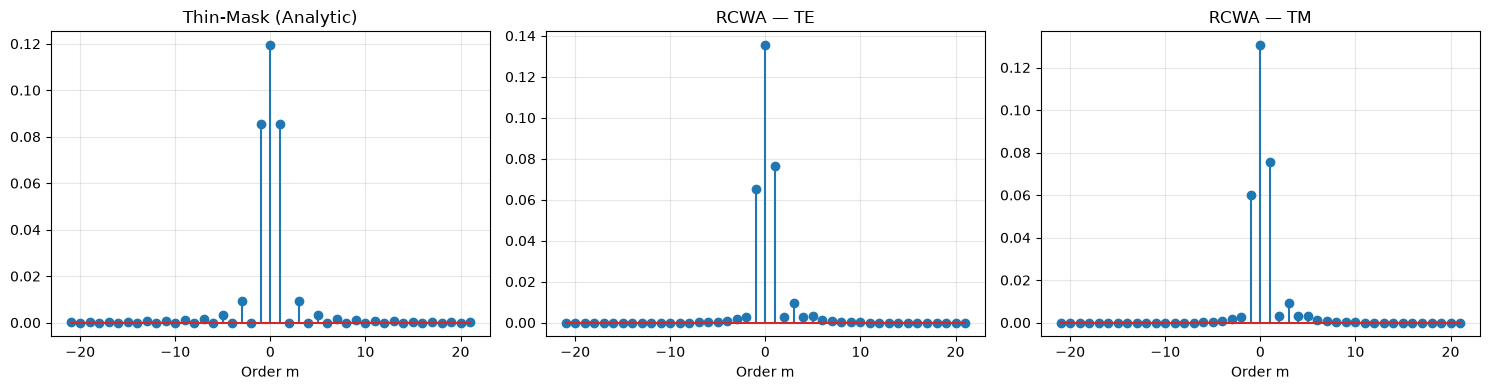

TE: |−1|/|+1| = 0.855
TM: |−1|/|+1| = 0.796


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

thin_int = np.abs(amps_thin.numpy())**2
te_int = np.array([eff_te.get(m, 0.0) for m in order_indices])
tm_int = np.array([eff_tm.get(m, 0.0) for m in order_indices])

axes[0].stem(order_indices, thin_int)
axes[0].set_title("Thin-Mask (Analytic)")
axes[1].stem(order_indices, te_int)
axes[1].set_title("RCWA — TE")
axes[2].stem(order_indices, tm_int)
axes[2].set_title("RCWA — TM")
for ax in axes:
    ax.set_xlabel("Order m")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Asymmetry check (±1 orders)
print(f"TE: |−1|/|+1| = {eff_te.get(-1,0)/max(eff_te.get(1,0),1e-12):.3f}")
print(f"TM: |−1|/|+1| = {eff_tm.get(-1,0)/max(eff_tm.get(1,0),1e-12):.3f}")


## 4. RCWA Convergence

The Fourier series of a binary grating converges slowly. The table shows how the 0th and +1 orders
settle with the number of retained orders for the same mask; the pipeline default is 21.

In [7]:
print(" orders |  0th order  |  +1 order")
for n in (11, 21, 31, 41, 61):
    s = RCWA1D(RCWAConfig(wavelength=wavelength_nm * 1e-9, n_orders=n, theta=theta_deg,
                          polarization="TE", device="cpu"))
    eff = s.diffraction_efficiency(s.solve(
        eps_profile, thicknesses, period_mask_m,
        n_incident=torch.tensor([1.0 + 0.0j, 1.0 + 0.0j], dtype=torch.complex128),
        ml_stack=ml_stack,
    ))
    print(f"{n:7d} | {eff.get(0, 0):10.5f} | {eff.get(1, 0):9.5f}")

 orders |  0th order  |  +1 order


     11 |    0.13333 |   0.07617


     21 |    0.13539 |   0.07638


     31 |    0.13612 |   0.07639


     41 |    0.13623 |   0.07642


     61 |    0.13630 |   0.07642


## 5. Sidewall Taper

Real absorbers are slightly tapered. `RCWA1D.solve` handles one lamellar layer; a tapered sidewall
needs a staircase of layers cascaded with an S-matrix, which is not implemented. The pipeline
therefore rejects `absorber_taper_deg ≠ 90` instead of silently ignoring it. (An earlier version of
this section compared the 60 nm vertical absorber with the first 7.5 nm slice of a staircase, in
vacuum; that did not model a taper.)

In [8]:
try:
    run_simulation(SimulationConfig(use_rcwa=True, absorber_taper_deg=88.0, grid=64))
except NotImplementedError as exc:
    print("Rejected as expected:", str(exc).split(";")[0])

Rejected as expected: absorber_taper_deg / mask_undercut_nm are not implemented in the RCWA mask geometry (binary vertical-sidewall grating only)


## 6. Multilayer Roughness

Interface roughness (Névot–Croce factor) damps reflectivity — affecting the mask background level.


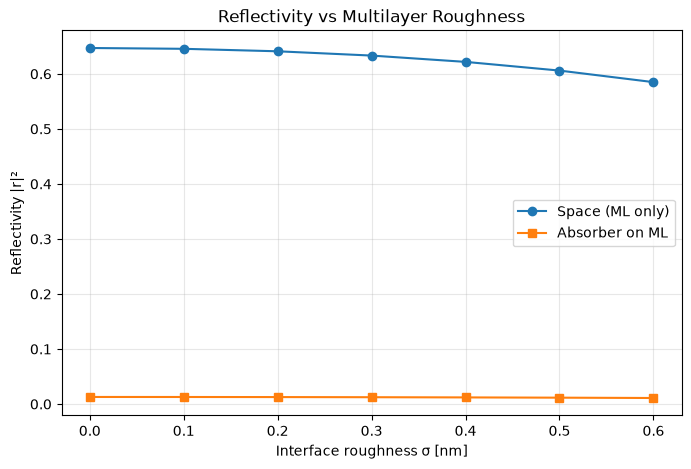

Space reflectivity drop (0 → 0.6 nm): 0.647 → 0.585


In [9]:
roughness_vals = np.linspace(0, 0.6, 7)
r_space_r, r_abs_r = [], []

for rough in roughness_vals:
    _, rs = reflectivity(ml_stack.n_layers, ml_stack.thicknesses, wl, theta_t,
                         n_substrate=n_sub, roughness_nm=rough)
    r_space_r.append(abs(rs[0])**2)
    _, ra = reflectivity(full_n, full_d, wl, theta_t,
                         n_substrate=n_sub, roughness_nm=rough)
    r_abs_r.append(abs(ra[0])**2)

plt.figure(figsize=(8, 5))
plt.plot(roughness_vals, r_space_r, "o-", label="Space (ML only)")
plt.plot(roughness_vals, r_abs_r, "s-", label="Absorber on ML")
plt.xlabel("Interface roughness σ [nm]")
plt.ylabel("Reflectivity |r|²")
plt.title("Reflectivity vs Multilayer Roughness")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Space reflectivity drop (0 → 0.6 nm): {r_space_r[0]:.3f} → {r_space_r[-1]:.3f}")


## 7. Best Focus: Thin Mask vs RCWA in the Pipeline

The pipeline runs the thin-mask model by default and the RCWA mask model with `use_rcwa=True`.
A thin mask images symmetrically through focus, so its best focus is at 0; the absorber topography
in the RCWA model shifts it. Best focus is taken here as the focus of maximum NILS (64 nm pitch,
NA 0.33, 20 mJ/cm², grid 128, 5 nm focus steps).

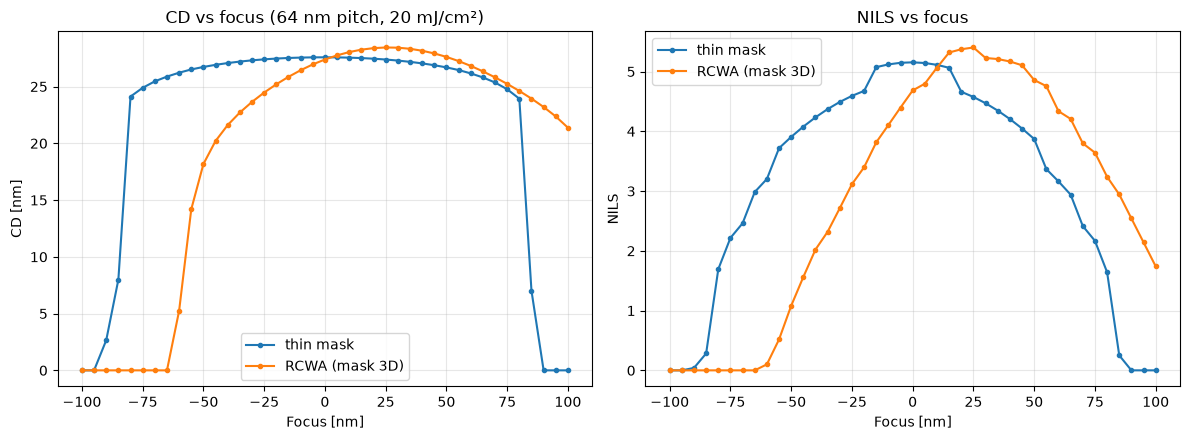

thin mask: best focus (max NILS) +0 nm, NILS 5.155, CD 27.58 nm
RCWA     : best focus (max NILS) +25 nm, NILS 5.403, CD 28.44 nm


In [10]:
focuses = np.arange(-100.0, 100.1, 5.0)
curves = {}
for use_rcwa in (False, True):
    cds, nls = [], []
    for f in focuses:
        cfg = SimulationConfig(
            period_nm=64.0, line_width_nm=32.0, dose_mj_cm2=20.0,
            focus_nm=float(f), grid=128, use_rcwa=use_rcwa,
            resist_model="aerial_threshold",
        )
        r = run_simulation(cfg)
        cds.append(r.cd_nm)
        nls.append(r.nils_value)
    curves[use_rcwa] = (np.array(cds), np.array(nls))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for use_rcwa, label in ((False, "thin mask"), (True, "RCWA (mask 3D)")):
    cds, nls = curves[use_rcwa]
    ax1.plot(focuses, cds, "o-", ms=3, label=label)
    ax2.plot(focuses, nls, "o-", ms=3, label=label)
ax1.set_xlabel("Focus [nm]"); ax1.set_ylabel("CD [nm]")
ax1.set_title("CD vs focus (64 nm pitch, 20 mJ/cm²)"); ax1.grid(True, alpha=0.3); ax1.legend()
ax2.set_xlabel("Focus [nm]"); ax2.set_ylabel("NILS")
ax2.set_title("NILS vs focus"); ax2.grid(True, alpha=0.3); ax2.legend()
plt.tight_layout()
plt.show()

for use_rcwa, label in ((False, "thin mask"), (True, "RCWA")):
    cds, nls = curves[use_rcwa]
    i = int(np.argmax(nls))
    print(f"{label:9s}: best focus (max NILS) {focuses[i]:+.0f} nm, NILS {nls[i]:.3f}, CD {cds[i]:.2f} nm")

## 8. Pitch Dependence of Best Focus


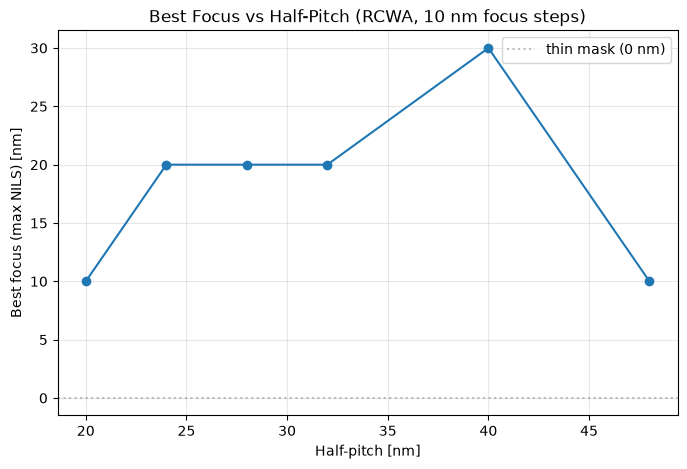

pitch  40 nm: best focus +10 nm
pitch  48 nm: best focus +20 nm
pitch  56 nm: best focus +20 nm
pitch  64 nm: best focus +20 nm
pitch  80 nm: best focus +30 nm
pitch  96 nm: best focus +10 nm


In [11]:
pitches = np.array([40, 48, 56, 64, 80, 96])
focuses_p = np.arange(-100.0, 100.1, 10.0)
bfs = []

for p in pitches:
    nls = [
        run_simulation(SimulationConfig(
            period_nm=float(p), line_width_nm=p / 2, dose_mj_cm2=20.0,
            focus_nm=float(f), grid=128, use_rcwa=True, resist_model="aerial_threshold",
        )).nils_value
        for f in focuses_p
    ]
    bfs.append(focuses_p[int(np.argmax(nls))])

plt.figure(figsize=(8, 5))
plt.plot(pitches / 2, bfs, "o-")
plt.axhline(0, color="gray", linestyle=":", alpha=0.5, label="thin mask (0 nm)")
plt.xlabel("Half-pitch [nm]")
plt.ylabel("Best focus (max NILS) [nm]")
plt.title("Best Focus vs Half-Pitch (RCWA, 10 nm focus steps)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for p, b in zip(pitches, bfs):
    print(f"pitch {p:3d} nm: best focus {b:+.0f} nm")

## Summary

| Effect | Thin mask | RCWA (mask 3D) |
|--------|-----------|----------------|
| **±1 orders** | Symmetric | Asymmetric: \|−1\|/\|+1\| = 0.86 (TE), 0.80 (TM); weak ±2 orders (≈ 0.003) that a 1:1 thin mask forbids |
| **Phase** | Analytic, binary | Topography-dependent |
| **Best focus (64 nm pitch, NA 0.33)** | 0 nm | +25 nm (max NILS, 5 nm steps); +10…+30 nm over 40–96 nm pitch (10 nm steps) |
| **Polarisation** | Scalar | TE ≠ TM |
| **Sidewall taper** | Not modelled | Not modelled (rejected; needs a multi-layer RCWA cascade) |

**Integration status (2.2.1):**
- RCWA solver (`euvsimulator.mask3d.rcwa_torch`) and mask geometry builder
  (`euvsimulator.mask3d.geometry`): implemented and tested against the transfer-matrix and Fresnel
  limits (`tests/test_rcwa_physics.py`).
- Pipeline: `SimulationConfig(use_rcwa=True)` or `euv simulate --use-rcwa` replaces the analytic
  Fourier coefficients with RCWA orders; the RCWA sees the physical mask (`mask_demagnification`, 4×).
- 21 retained orders (the pipeline default) put the 0th order within 0.7 % of the 61-order value.
- Not implemented: `absorber_taper_deg` / `mask_undercut_nm` in the pipeline (vertical sidewalls
  only; other values are rejected) and the anamorphic high-NA pupil.
- The best-focus shift above is a model result; it has not been compared with a measurement.